# 03 · Cómo se evalúa — de la salida del modelo a cada número del paper

Este notebook es la **fuente única** de la parte evaluativa. Recorre, paso a paso y con
datos reales, cómo se pasa del JSON que devuelve Gemini a un Service F1 y un Edge F1,
y qué decide exactamente cada regla.

Está escrito para **auditarlo a mano**: cada métrica se calcula primero en un ejemplo
mínimo que se puede seguir con lápiz, después sobre un video real, y recién al final
sobre el panel de 30. En cada paso se compara contra el evaluador de producción
(`scripts/utils/evaluate_graphs.evaluate_pair`) y se corta si no coincide.

## Las dos evaluaciones

| | qué relaja | para qué sirve |
|---|---|---|
| **Estricta** | nada — es el evaluador de producción | métrica principal, la que se reporta |
| **Permisiva (2 reglas)** | subtipo de actor + dirección de la flecha | métrica secundaria, aísla el error que no es "de arquitectura" |

> **Sobre la permisiva de 3 reglas:** existe en el repo
> (`scripts/ablation/evaluate_permissive_panel.py`) y **este notebook no la usa como
> métrica**. La tercera regla —colapsar a conjunto para ignorar instancias duplicadas—
> borra a propósito una capacidad que el prompt implementa (§7.3). Aparece acá solo
> como término de comparación, para mostrar cuánto infla.

## Secciones

1. Preparación y datos
2. Cómo se construye el grafo, y la regla que gobierna todo: se compara **por servicio**
3. Precision, Recall y F1 desde cero — **acá está el castigo por alucinar**
4. Métrica estricta · servicios
5. Métrica estricta · aristas
6. Anatomía del error: por qué se pierden las aristas
7. Métrica permisiva de 2 reglas
8. Panel de 30: tabla comparativa y gráficas
9. Exportar resultados

## 1 · Preparación y datos

Tres insumos, todos ya en el repo — este notebook **no llama a ninguna API**:

- `data/cloudscape_gt/<video>.graphml` — el **ground truth** de Cloudscape (FAST25).
- `results/ablation/<corrida>/run.json` — la salida del modelo. Cada corrida guarda el
  `analysis` completo (nodos y aristas) por video, así que se puede re-evaluar gratis.
- `data/cloudscape_gt/services.csv` — el **catálogo cerrado** de servicios. Además del
  nombre trae una columna `capability`, que es la que agrupa actores en la permisiva.

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

sys.path.append("..")
from scripts.core.graph_builder import create_graph_from_cloudscape_json
from scripts.utils.evaluate_graphs import evaluate_pair, load_services_catalog

GT_DIR = Path("../data/cloudscape_gt")
ABL    = Path("../reports/ablation")

# Corrida de referencia: produccion sobre el panel de 30 (prompt de produccion,
# sha ed1d85054d73). Cambiar solo esta linea re-evalua todo el notebook contra otra corrida.
RUN_DIR = ABL / "2026-08-29_0715_STAGE2_V6_CORRECTED_cell9_p30_rep4"

CATALOG = load_services_catalog(GT_DIR / "services.csv")
RUN = json.loads((RUN_DIR / "run.json").read_text(encoding="utf-8"))
RESULTS = {r["video_id"]: r for r in RUN["results"] if r["status"] == "success"}

pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 120)

print(f"corrida     : {RUN_DIR.name}")
print(f"prompt      : {RUN['stage2_prompt']['name']} · sha {RUN['stage2_prompt']['sha256'][:12]}")
print(f"modelo      : {RUN['model']}")
print(f"videos      : {len(RESULTS)}")
print(f"catalogo    : {len(CATALOG)} servicios")
print(f"metricas ya guardadas por la corrida: {RUN['metrics']}")

corrida     : 2026-08-29_0715_STAGE2_V6_CORRECTED_cell9_p30_rep4
prompt      : STAGE2_V6_CORRECTED · sha ed1d85054d73
modelo      : gemini-3.6-flash
videos      : 30
catalogo    : 169 servicios
metricas ya guardadas por la corrida: {'service_f1_mean': 86.13, 'edge_f1_mean': 57.87, 'n_success': 30}


### Qué hay dentro de un `analysis`

El modelo devuelve el grafo en el esquema de Cloudscape: una lista de `nodes` y una de
`edges` que se referencian por `id`. Los `id` los inventa el modelo en cada llamada.

In [2]:
EJEMPLO = "-wLEkq21cvA"   # migracion on-prem: tiene duplicados y bidireccionales, sirve para todo el notebook

analysis = RESULTS[EJEMPLO]["analysis"]
print("NODOS generados:")
display(pd.DataFrame(analysis["nodes"])[["id", "service", "name"]])
print("\nARISTAS generadas:")
display(pd.DataFrame(analysis["edges"])[["source", "target", "type"]])

NODOS generados:


,id,service,name
0,0,ThirdParty,ON-PREM
1,1,AppDiscovery,APP DISCOVERY SERVICE
2,2,ThirdParty,SLACK
3,3,DynamoDB,DYNAMODB
4,4,EC2,EC2 MIGRATION FACTORY
5,5,ThirdParty,CLOUDENDURE
6,6,EC2,EC2 HOT REPLICA
7,7,EC2,EC2 TARGET



ARISTAS generadas:


,source,target,type
0,0,1,data
1,0,6,data
2,2,4,control
3,4,1,data
4,4,3,data
5,4,5,control
6,5,6,control
7,4,7,control


## 2 · Del JSON al grafo, y la regla que gobierna todo

`create_graph_from_cloudscape_json` convierte ese JSON en un `networkx.MultiDiGraph`.
El ground truth se lee del `.graphml` y ya viene en la misma forma. A partir de acá, los
dos lados son grafos comparables.

### La regla más importante de toda la evaluación

> **Se compara por `service`, nunca por `id` de nodo.**

Está en `evaluate_graphs.py` como comentario explícito: *"ID-agnostic — we compare by
service names"*. Es una decisión forzada, no una preferencia:

- Los `id` que emite el modelo (`"0"`, `"1"`, `"2"`…) son **arbitrarios**: no hay ninguna
  garantía de que el nodo `"3"` del modelo sea el nodo `"3"` del ground truth.
- Emparejar nodos por identidad exigiría resolver antes una correspondencia entre los dos
  grafos, que es un problema tan difícil como la tarea misma.

**Consecuencia que hay que tener presente todo el notebook:** una arista no es
"del nodo 2 al nodo 5", es **"de un `EC2` a un `S3`"**. Dos aristas distintas del grafo
colapsan a la misma comparación si conectan los mismos dos *tipos* de servicio.

In [3]:
def build_gen(video_id: str) -> nx.MultiDiGraph:
    return create_graph_from_cloudscape_json(RESULTS[video_id]["analysis"], video_id=video_id)

def build_gt(video_id: str) -> nx.MultiDiGraph:
    return nx.read_graphml(GT_DIR / f"{video_id}.graphml")

G_gen, G_gt = build_gen(EJEMPLO), build_gt(EJEMPLO)

def tabla_aristas(G, titulo):
    filas = [{"origen_id": u, "destino_id": v,
              "origen_svc": G.nodes[u].get("service"), "destino_svc": G.nodes[v].get("service")}
             for u, v in G.edges()]
    print(f"\n{titulo}  ({G.number_of_nodes()} nodos, {G.number_of_edges()} aristas)")
    display(pd.DataFrame(filas))

tabla_aristas(G_gen, "GENERADO")
tabla_aristas(G_gt, "GROUND TRUTH")

✓ Graph created: 8 nodes, 8 edges


GENERADO  (8 nodos, 8 aristas)


,origen_id,destino_id,origen_svc,destino_svc
0,0,1,ThirdParty,AppDiscovery
1,0,6,ThirdParty,EC2
2,2,4,ThirdParty,EC2
3,4,1,EC2,AppDiscovery
4,4,3,EC2,DynamoDB
5,4,5,EC2,ThirdParty
6,4,7,EC2,EC2
7,5,6,ThirdParty,EC2



GROUND TRUTH  (9 nodos, 10 aristas)


,origen_id,destino_id,origen_svc,destino_svc
0,0,2,AppDiscovery,EC2
1,2,0,EC2,AppDiscovery
2,2,8,EC2,ThirdParty
3,2,4,EC2,EC2
4,5,1,UserCompanyAgent,DynamoDB
5,5,7,UserCompanyAgent,ThirdParty
6,6,0,ThirdParty,AppDiscovery
7,6,3,ThirdParty,EC2
8,7,2,ThirdParty,EC2
9,8,2,ThirdParty,EC2


Fijate en el ground truth de este video: las aristas `2→0` y `0→2` conectan **el mismo
par de nodos en los dos sentidos** (es una relación bidireccional), y `ThirdParty → EC2`
aparece **tres veces** desde *pares de nodos distintos* (tres servidores on-prem, cada uno
migrando a su instancia). Esas dos situaciones son la razón de ser de todo lo que sigue.

## 3 · Precision, Recall y F1 desde cero

Todas las métricas del proyecto son la misma fórmula aplicada a colecciones distintas.
Conviene fijarla acá porque **es donde vive el castigo por alucinar**, que es lo que
querías revisar.

Con `GEN` = lo que produjo el modelo y `GT` = lo correcto:

$$\text{Precision} = \frac{|\,GEN \cap GT\,|}{|GEN|}
\qquad
\text{Recall} = \frac{|\,GEN \cap GT\,|}{|GT|}
\qquad
F_1 = \frac{2 \cdot P \cdot R}{P + R}$$

### Qué castiga cada una

| El modelo… | efecto | por qué |
|---|---|---|
| **inventa** un servicio que el GT no tiene (*alucinación*) | **baja Precision** | crece el denominador `\|GEN\|`, la intersección no |
| **omite** un servicio que el GT sí tiene | **baja Recall** | el denominador `\|GT\|` queda igual, la intersección baja |
| acierta | suben las dos | — |

**Respuesta directa a tu pregunta: sí, generar servicios de más se castiga**, y se castiga
vía Precision. No es un castigo aparte ni un descuento: es la definición misma de
Precision. Y como el F1 es la media armónica, **basta que una de las dos caiga para que el
F1 caiga** — la media armónica se pega al menor de los dos, no al promedio.

Esto último es lo que hace al F1 preferible a un simple porcentaje de aciertos: un modelo
que emite *todos* los servicios del catálogo tendría Recall perfecto, y el F1 lo hunde
igual porque su Precision sería mínima.

In [4]:
def prf1(inter: int, n_gen: int, n_gt: int) -> tuple[float, float, float]:
    """Precision, Recall, F1. Unica formula de todo el notebook."""
    p = inter / n_gen if n_gen else 0.0
    r = inter / n_gt if n_gt else 0.0
    f = 2 * p * r / (p + r) if (p + r) else 0.0
    return p, r, f


# --- ejemplo minimo, seguible con lapiz ---
gt_juguete = {"S3", "Lambda", "DynamoDB"}

escenarios = {
    "perfecto":                {"S3", "Lambda", "DynamoDB"},
    "omite 1 (falta Dynamo)":  {"S3", "Lambda"},
    "alucina 1 (agrega EC2)":  {"S3", "Lambda", "DynamoDB", "EC2"},
    "alucina 3":               {"S3", "Lambda", "DynamoDB", "EC2", "SNS", "SQS"},
    "omite 1 y alucina 1":     {"S3", "Lambda", "EC2"},
    "dispara a todo":          {"S3", "Lambda", "DynamoDB", "EC2", "SNS", "SQS", "RDS", "EKS", "Glue"},
}

filas = []
for nombre, gen in escenarios.items():
    p, r, f = prf1(len(gen & gt_juguete), len(gen), len(gt_juguete))
    filas.append({"escenario": nombre, "|GEN|": len(gen), "aciertos": len(gen & gt_juguete),
                  "Precision": round(p, 3), "Recall": round(r, 3), "F1": round(f, 3)})

display(pd.DataFrame(filas).set_index("escenario"))

,|GEN|,aciertos,Precision,Recall,F1
escenario,,,,,
perfecto,3,3,1.000,1.000,1.000
omite 1 (falta Dynamo),2,2,1.000,0.667,0.800
alucina 1 (agrega EC2),4,3,0.750,1.000,0.857
alucina 3,6,3,0.500,1.000,0.667
omite 1 y alucina 1,3,2,0.667,0.667,0.667
dispara a todo,9,3,0.333,1.000,0.500


Leelo por filas:

- **`alucina 1`** tiene Recall **perfecto** (encontró los 3 que debía) y aun así el F1 baja
  de 1.000 a 0.857. Eso es exactamente el castigo por generar de más.
- **`dispara a todo`** encuentra los 3 correctos —Recall 1.0— y termina con F1 0.500. Es la
  demostración de por qué el Recall solo no sirve como métrica.
- **`omite 1 y alucina 1`** es el caso más común en la práctica: se pierde por los dos lados
  a la vez.

## 4 · Métrica estricta · servicios

Ahora la misma fórmula sobre los servicios de un video real.

### Detalle que casi nadie nota: el Service F1 que se reporta usa **conjunto**, no multiconjunto

`evaluate_pair` calcula las dos versiones, pero la que sale publicada como *Service F1* es
la de **conjunto único**:

```python
gen_svc_set = extract_service_set(gen_graph)          # <- set()
svc_prec, svc_rec, svc_f1 = set_precision_recall(...)  # <- este es el que se reporta

gen_svc_list = extract_service_multiset(gen_graph)     # <- list, con repetidos
ms_prec, ms_rec, ms_f1 = multiset_precision_recall(...) # <- se guarda como ms_f1, no se publica
```

**Implicancia práctica fuerte:** si el ground truth ya tiene un `EC2`, agregar un segundo,
tercer o cuarto nodo `EC2` **no cuesta nada en Service F1**. Lo que cuesta es introducir un
*tipo* de servicio que el GT no tiene. Duplicar es gratis; inventar es caro.

In [5]:
def servicios(G, como_conjunto=True):
    vals = [G.nodes[n].get("service", "") for n in G.nodes()]
    return set(vals) if como_conjunto else vals

gen_set, gt_set = servicios(G_gen), servicios(G_gt)

aciertos    = sorted(gen_set & gt_set)
alucinados  = sorted(gen_set - gt_set)
faltantes   = sorted(gt_set - gen_set)

p, r, f = prf1(len(gen_set & gt_set), len(gen_set), len(gt_set))

print(f"video: {EJEMPLO}\n")
print(f"GEN  ({len(gen_set)}): {sorted(gen_set)}")
print(f"GT   ({len(gt_set)}): {sorted(gt_set)}\n")
print(f"  aciertos   ({len(aciertos)}): {aciertos}")
print(f"  ALUCINADOS ({len(alucinados)}): {alucinados}   -> castigan Precision")
print(f"  FALTANTES  ({len(faltantes)}): {faltantes}   -> castigan Recall\n")
print(f"  Precision = {len(aciertos)}/{len(gen_set)} = {p:.4f}")
print(f"  Recall    = {len(aciertos)}/{len(gt_set)} = {r:.4f}")
print(f"  F1        = {f:.4f}")

# contraste conjunto vs multiconjunto
gen_l, gt_l = servicios(G_gen, False), servicios(G_gt, False)
cg, ct = Counter(gen_l), Counter(gt_l)
inter_ms = sum((cg & ct).values())
_, _, f_ms = prf1(inter_ms, sum(cg.values()), sum(ct.values()))
print(f"\n  F1 con multiconjunto (ms_f1, NO se publica) = {f_ms:.4f}")
print(f"  conteos GEN: {dict(cg)}")
print(f"  conteos GT : {dict(ct)}")

video: -wLEkq21cvA

GEN  (4): ['AppDiscovery', 'DynamoDB', 'EC2', 'ThirdParty']
GT   (5): ['AppDiscovery', 'DynamoDB', 'EC2', 'ThirdParty', 'UserCompanyAgent']

  aciertos   (4): ['AppDiscovery', 'DynamoDB', 'EC2', 'ThirdParty']
  ALUCINADOS (0): []   -> castigan Precision
  FALTANTES  (1): ['UserCompanyAgent']   -> castigan Recall

  Precision = 4/4 = 1.0000
  Recall    = 4/5 = 0.8000
  F1        = 0.8889

  F1 con multiconjunto (ms_f1, NO se publica) = 0.9412
  conteos GEN: {'ThirdParty': 3, 'AppDiscovery': 1, 'DynamoDB': 1, 'EC2': 3}
  conteos GT : {'AppDiscovery': 1, 'DynamoDB': 1, 'EC2': 3, 'UserCompanyAgent': 1, 'ThirdParty': 3}


### Verificación contra el evaluador de producción

In [6]:
oficial = evaluate_pair(G_gen, G_gt, EJEMPLO, CATALOG)

assert abs(oficial["svc_f1"] - f) < 1e-9, "el Service F1 recalculado no coincide"
assert abs(oficial["ms_f1"] - f_ms) < 1e-9, "el ms_f1 recalculado no coincide"
assert sorted(oficial["services_hallucinated"]) == alucinados
assert sorted(oficial["services_missing"]) == faltantes
print(f"OK · coincide con evaluate_pair: svc_f1={oficial['svc_f1']:.4f}  ms_f1={oficial['ms_f1']:.4f}")

OK · coincide con evaluate_pair: svc_f1=0.8889  ms_f1=0.9412


### El costo de alucinar, medido

Tomamos el grafo generado real y le inyectamos servicios que el GT no tiene, uno por uno,
para ver la curva de daño. Nada más cambia.

,|GEN|,Precision,Recall,Service F1
servicios inventados,,,,
0,4,1.000,0.8,0.889
1,5,0.800,0.8,0.800
2,6,0.667,0.8,0.727
3,7,0.571,0.8,0.667
4,8,0.500,0.8,0.615
5,9,0.444,0.8,0.571
6,10,0.400,0.8,0.533


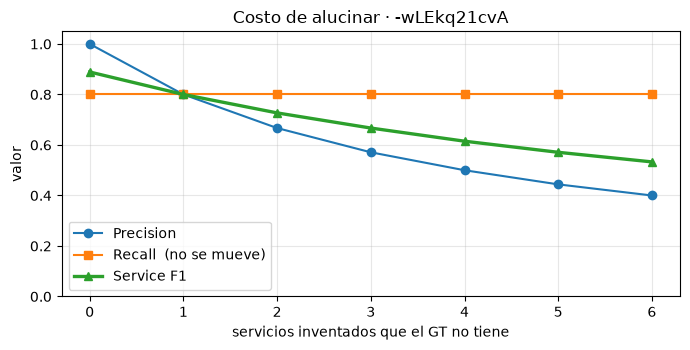

In [7]:
inventados = ["EKS", "SageMaker", "Redshift", "Athena", "Neptune", "Glue"]

filas = []
for k in range(len(inventados) + 1):
    conjunto = gen_set | set(inventados[:k])
    p_, r_, f_ = prf1(len(conjunto & gt_set), len(conjunto), len(gt_set))
    filas.append({"servicios inventados": k, "|GEN|": len(conjunto),
                  "Precision": round(p_, 3), "Recall": round(r_, 3), "Service F1": round(f_, 3)})

dfh = pd.DataFrame(filas).set_index("servicios inventados")
display(dfh)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(dfh.index, dfh["Precision"],  marker="o", label="Precision")
ax.plot(dfh.index, dfh["Recall"],     marker="s", label="Recall  (no se mueve)")
ax.plot(dfh.index, dfh["Service F1"], marker="^", lw=2.4, label="Service F1")
ax.set_xlabel("servicios inventados que el GT no tiene")
ax.set_ylabel("valor")
ax.set_title(f"Costo de alucinar · {EJEMPLO}")
ax.set_ylim(0, 1.05); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

El Recall es una línea plana: **alucinar nunca ayuda ni perjudica al Recall**. Toda la
caída del F1 viene de la Precision. Es el mecanismo que evita que el modelo mejore su
puntaje enumerando servicios "por las dudas".

### 4.2 · Conjunto vs multiconjunto — qué NO castiga el Service F1

Vale insistir en la consecuencia de que el Service F1 publicado use **conjunto**, porque es
contraintuitiva y define qué se puede afirmar con esa cifra.

| el modelo… | ¿lo castiga `svc_f1`? |
|---|---|
| inventa un **tipo** que el GT no tiene | **sí** — cae la precisión |
| genera **más instancias** de un tipo que el GT ya tiene | **no** — es gratis |
| **colapsa** instancias (1 donde el GT tiene 3) | **no** — también es gratis |

O sea: **inventar es caro, duplicar es gratis.** Se demuestra con un ejemplo mínimo donde
el ground truth tiene un servicio repetido.

In [8]:
gt_juguete = ["S3", "Lambda", "Lambda"]        # Lambda aparece DOS veces

casos = {
    "exacto":                          ["S3", "Lambda", "Lambda"],
    "duplica Lambda (4 en vez de 2)":  ["S3", "Lambda", "Lambda", "Lambda", "Lambda"],
    "inventa un tipo nuevo (EC2)":     ["S3", "Lambda", "Lambda", "EC2"],
    "colapsa Lambda a una sola":       ["S3", "Lambda"],
}

filas = []
for nombre, gen in casos.items():
    _, _, f_conj = prf1(len(set(gen) & set(gt_juguete)), len(set(gen)), len(set(gt_juguete)))
    cg, ct = Counter(gen), Counter(gt_juguete)
    _, _, f_multi = prf1(sum((cg & ct).values()), sum(cg.values()), sum(ct.values()))
    filas.append({"caso": nombre,
                  "CONJUNTO (svc_f1, publicado)": round(f_conj, 3),
                  "MULTICONJUNTO (ms_f1)": round(f_multi, 3)})

display(pd.DataFrame(filas).set_index("caso"))
print("Fijate en la fila 'duplica': el conjunto da 1.000 — duplicar instancias no cuesta nada.")

,"CONJUNTO (svc_f1, publicado)",MULTICONJUNTO (ms_f1)
caso,,
exacto,1.0,1.000
duplica Lambda (4 en vez de 2),1.0,0.750
inventa un tipo nuevo (EC2),0.8,0.857
colapsa Lambda a una sola,1.0,0.800


Fijate en la fila 'duplica': el conjunto da 1.000 — duplicar instancias no cuesta nada.


#### Cuánto crédito regala esa decisión, sobre el corpus real

No es una curiosidad de juguete: **el 15.3 % de los nodos del ground truth son instancias
repetidas**. Se mide la diferencia sobre los 336 videos usables.

n = 336 videos usables


,media
conjunto (svc_f1),86.73
multiconjunto (ms_f1),84.29
diferencia,2.44



nodos del GT que son instancias repetidas: 529/3478 = 15.2 %


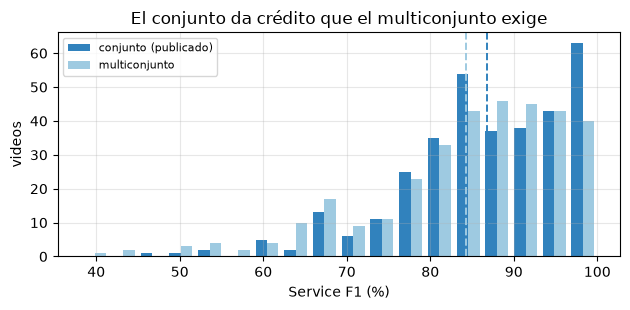

In [9]:
GEN_DIR = Path("../data/graphs")

pares = []
for f in sorted(GEN_DIR.glob("*.graphml")):
    g = GT_DIR / f"{f.stem}.graphml"
    if not g.exists():
        continue
    r = evaluate_pair(nx.read_graphml(f), nx.read_graphml(g), f.stem, CATALOG)
    if r["graph_usable"]:
        pares.append((r["svc_f1"], r["ms_f1"]))

comp = pd.DataFrame(pares, columns=["conjunto (svc_f1)", "multiconjunto (ms_f1)"]) * 100
resumen = comp.mean().to_frame("media").round(2)
resumen.loc["diferencia"] = round(comp.iloc[:, 0].mean() - comp.iloc[:, 1].mean(), 2)
print(f"n = {len(comp)} videos usables")
display(resumen)

# Cuantos nodos del GT son instancias repetidas
rep = tot = 0
for f in sorted(GT_DIR.glob("*.graphml")):
    c = Counter(a.get("service", "") for _, a in nx.read_graphml(f).nodes(data=True))
    tot += sum(c.values()); rep += sum(v - 1 for v in c.values() if v > 1)
print(f"\nnodos del GT que son instancias repetidas: {rep}/{tot} = {100*rep/tot:.1f} %")

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.hist([comp.iloc[:, 0], comp.iloc[:, 1]], bins=18,
        label=["conjunto (publicado)", "multiconjunto"], color=["#3182bd", "#9ecae1"])
for v, c in [(comp.iloc[:, 0].mean(), "#3182bd"), (comp.iloc[:, 1].mean(), "#9ecae1")]:
    ax.axvline(v, color=c, ls="--", lw=1.4)
ax.set_xlabel("Service F1 (%)"); ax.set_ylabel("videos"); ax.legend(fontsize=8); ax.grid(alpha=.3)
ax.set_title("El conjunto da crédito que el multiconjunto exige")
plt.tight_layout(); plt.show()

#### ¿Está bien elegir el conjunto?

Es defendible, **pero no es gratis** y conviene declararlo antes de que lo pregunte un
revisor.

**A favor.** Cuántas cajas del mismo servicio dibujó el presentador es en buena medida una
decisión de dibujo, no de arquitectura: tres EC2 pueden ser una flota. Y el propio ground
truth es inconsistente ahí — en `hMK2NJ-q9nc` colapsa tres EC2 dibujados en **un** nodo con
`AUTOSCALE: true`, mientras que en `Cgv0kfp_6xQ` mantiene cuatro microservicios como cuatro
nodos `EKS`.

**En contra.** El prompt de producción implementa a propósito la *fusión lógica dinámica*
(su regla 4: fusionar si actúan como una unidad, separar si hacen pasos distintos). **La
métrica de conjunto premia igual al modelo que distingue instancias y al que no** — o sea,
no mide una capacidad que el sistema sí tiene.

**Recomendación para el paper:** no cambiar la métrica principal, pero **reportar las dos**.
Una línea alcanza:

> *Service F1 se calcula sobre el conjunto único de servicios, siguiendo la convención del
> evaluador. Bajo multiconjunto, que además exige acertar la multiplicidad, la media cae de
> 86.73 a 84.29 (−2.44 pts). Se reportan ambas porque la elección afecta lo que se mide: el
> conjunto no penaliza duplicar ni colapsar instancias, y el 15.3 % de los nodos del ground
> truth son instancias repetidas.*

`evaluate_pair` calculaba `ms_f1` desde siempre, pero **no llegaba al `results.csv`**. Se
agregó (`scripts/utils/evaluate_standard.py`), junto con `ms_precision` y `ms_recall` y una
fila en la tabla de resumen, para que la cifra sea citable sin recalcularla a mano.

## 5 · Métrica estricta · aristas

Acá cambian dos cosas respecto de los servicios:

1. **Se usa multiconjunto**, no conjunto. Si el GT conecta `ThirdParty → EC2` tres veces,
   valen 3; encontrar una sola da Recall 1/3.
2. **El par es ordenado**: `(EC2, S3)` y `(S3, EC2)` son aristas **distintas**.

El `type` de la arista (`data` / `control` / `meta`) **no entra** en el Edge F1; se mide
aparte como `edge_type_accuracy`.

In [10]:
def pares_ordenados(G) -> Counter:
    """Multiconjunto de (servicio_origen, servicio_destino). Es lo que mide Edge F1."""
    return Counter((G.nodes[u].get("service", "?"), G.nodes[v].get("service", "?"))
                   for u, v in G.edges())

ge, gt_e = pares_ordenados(G_gen), pares_ordenados(G_gt)
inter = sum((ge & gt_e).values())
p_e, r_e, f_e = prf1(inter, sum(ge.values()), sum(gt_e.values()))

comp = pd.DataFrame({"GEN": pd.Series({f"{a} -> {b}": c for (a, b), c in ge.items()}),
                     "GT":  pd.Series({f"{a} -> {b}": c for (a, b), c in gt_e.items()})}).fillna(0).astype(int)
comp["min (cuenta)"] = comp[["GEN", "GT"]].min(axis=1)
display(comp.sort_values(["min (cuenta)", "GT"], ascending=False))

print(f"\ninterseccion de multiconjuntos = suma de la columna min = {inter}")
print(f"  Precision = {inter}/{sum(ge.values())} = {p_e:.4f}")
print(f"  Recall    = {inter}/{sum(gt_e.values())} = {r_e:.4f}")
print(f"  Edge F1   = {f_e:.4f}")
assert abs(oficial["edge_f1"] - f_e) < 1e-9
print(f"\nOK · coincide con evaluate_pair: edge_f1={oficial['edge_f1']:.4f}")

,GEN,GT,min (cuenta)
ThirdParty -> EC2,3,3,3
EC2 -> AppDiscovery,1,1,1
EC2 -> EC2,1,1,1
EC2 -> ThirdParty,1,1,1
ThirdParty -> AppDiscovery,1,1,1
AppDiscovery -> EC2,0,1,0
UserCompanyAgent -> DynamoDB,0,1,0
UserCompanyAgent -> ThirdParty,0,1,0
EC2 -> DynamoDB,1,0,0



interseccion de multiconjuntos = suma de la columna min = 7
  Precision = 7/8 = 0.8750
  Recall    = 7/10 = 0.7000
  Edge F1   = 0.7778

OK · coincide con evaluate_pair: edge_f1=0.7778


### Por qué el Edge F1 es siempre mucho más bajo que el Service F1

Tres razones se acumulan, y conviene tenerlas separadas:

1. **Un nodo ausente arrastra todas sus aristas.** Si falta un servicio, se pierden de una
   todas las conexiones que entraban y salían de él. El error de nodo se paga dos veces.
2. **La dirección tiene que acertarse.** Una flecha leída al revés no es "medio punto":
   suma un falso positivo *y* un falso negativo.
3. **Hay que acertar la cantidad.** Con multiconjunto, tres conexiones iguales exigen
   emitir tres.

La sección 6 mide cuánto pesa cada una.

## 6 · Anatomía del error: por qué se pierden las aristas

Clasificamos cada arista del GT que el modelo **no** produjo, en todo el panel, según la
causa. Es la descomposición que fundamenta las decisiones de la sección 7.

✓ Graph created: 9 nodes, 9 edges

✓ Graph created: 10 nodes, 4 edges

✓ Graph created: 8 nodes, 8 edges

✓ Graph created: 9 nodes, 10 edges

✓ Graph created: 7 nodes, 7 edges

...

✓ Graph created: 7 nodes, 6 edges

✓ Graph created: 10 nodes, 10 edges

✓ Graph created: 9 nodes, 11 edges

,aristas,%
causa,,
falta la arista de RETORNO,81,44.8
falta un nodo,61,33.7
"ambos nodos presentes, sin conexion",39,21.5



aristas del GT en el panel : 361
aristas del GT no generadas: 181 (50.1%)


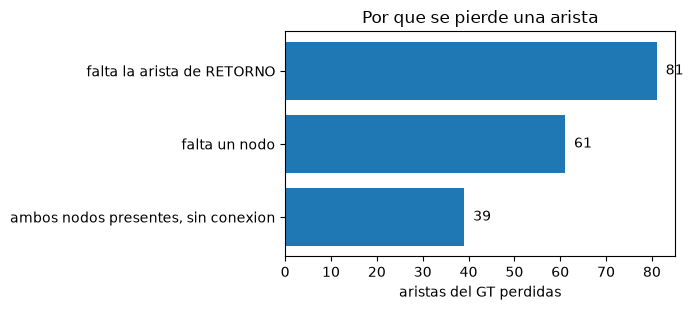

In [11]:
def clasificar_faltantes(G_gen, G_gt):
    """Para cada arista del GT ausente en GEN, por que falta."""
    gen_c, gt_c = pares_ordenados(G_gen), pares_ordenados(G_gt)
    faltan = gt_c - gen_c                      # resta de multiconjuntos
    gen_svcs = {G_gen.nodes[n].get("service", "") for n in G_gen}
    out = []
    for (a, b), n in faltan.items():
        if a not in gen_svcs or b not in gen_svcs:
            causa = "falta un nodo"
        elif gen_c.get((b, a), 0) > 0:
            causa = "falta la arista de RETORNO"
        else:
            causa = "ambos nodos presentes, sin conexion"
        out.append({"causa": causa, "arista": f"{a} -> {b}", "n": n})
    return out

todas = []
for vid in RESULTS:
    todas += clasificar_faltantes(build_gen(vid), build_gt(vid))

dfc = pd.DataFrame(todas)
resumen = dfc.groupby("causa")["n"].sum().sort_values(ascending=False).to_frame("aristas")
resumen["%"] = (100 * resumen["aristas"] / resumen["aristas"].sum()).round(1)
display(resumen)

total_gt = sum(build_gt(v).number_of_edges() for v in RESULTS)
print(f"\naristas del GT en el panel : {total_gt}")
print(f"aristas del GT no generadas: {resumen['aristas'].sum()} "
      f"({100*resumen['aristas'].sum()/total_gt:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(resumen.index[::-1], resumen["aristas"][::-1])
for i, v in enumerate(resumen["aristas"][::-1]):
    ax.text(v + 2, i, str(v), va="center")
ax.set_xlabel("aristas del GT perdidas"); ax.set_title("Por que se pierde una arista")
plt.tight_layout(); plt.show()

La causa dominante es **la arista de retorno**: el modelo conectó bien `a→b` pero no puso
`b→a`, y el ground truth tenía las dos. Eso motiva la regla B de la permisiva.

La segunda causa, **falta un nodo**, es la que confirma el punto 1 de la sección anterior:
el error de nodo se paga otra vez en aristas.

## 7 · Métrica permisiva de 2 reglas

La estricta mezcla dos cosas: errores de **arquitectura** (el modelo entendió mal el
sistema) y errores de **convención** (nombró distinto, o no pudo leer para dónde apunta una
flecha). La permisiva quita los segundos para dejar ver los primeros.

### Regla A · agrupar actores

Todo `User*` colapsa a `User`; todo `ThirdParty*` colapsa a `ThirdParty`.

**Justificación:** distinguir `UserConsumerWeb` de `UserConsumerMobile`, o
`UserCompanyDeveloper` de `UserCompanyAgent`, **no es determinable mirando la pizarra** —
es el mismo monigote dibujado. Penalizarlo mide la suerte del anotador, no la calidad de
la reconstrucción. (Lo vimos en carne propia anotando `1aYoIZvabbk`.)

La regla usa la columna `capability` del catálogo, no solo el prefijo del nombre.

### Regla B · aristas no dirigidas, sin castigar la bidireccionalidad ausente

Una arista pasa a ser un par **no ordenado** `{a, b}`, y **si dentro de un mismo grafo
existen `a→b` y `b→a`, cuentan como una sola**.

**Justificación:** la dirección de una flecha dibujada a mano es genuinamente ambigua, y
—más importante— si el GT marca una relación como bidireccional y el modelo la detectó en
un solo sentido, **entendió la conexión**. Castigarlo mide caligrafía.

### El detalle que hace toda la diferencia

Colapsar los bidireccionales hay que hacerlo **a nivel de par de nodos, antes** de traducir
a servicios:

1. primero `{(u,v) ordenado}` sobre los **id de nodo** → esto funde `a↔b` en uno;
2. recién después se mapea cada par de nodos a su par de servicios, como **multiconjunto**.

Así se logran las dos cosas a la vez: la bidireccionalidad deja de castigar, **pero las
repeticiones legítimas entre pares de nodos distintos se siguen contando**.

Si en cambio se ordena el par de servicios sin deduplicar por par de nodos, una relación
bidireccional del GT sigue valiendo 2 y el modelo que encontró un solo sentido **sigue
perdiendo recall** — es decir, la regla no hace lo que dice hacer. Volvemos sobre esto
en §7.3, porque es un error que ya está publicado en el `ara/`.

In [12]:
def norm_actor(svc: str) -> str:
    """REGLA A. Usa capability del catalogo, no solo el prefijo."""
    s = str(svc or "").strip()
    if not s or s == "?":
        return "Unknown"
    cap = CATALOG.get(s, {}).get("capability", "")
    if s.startswith("User") or cap == "User":
        return "User"
    if s.startswith("ThirdParty") or cap == "ThirdParty":
        return "ThirdParty"
    return s


def servicios_perm(G) -> set:
    """Nodos: mismo conjunto que la estricta, con la regla A aplicada."""
    return {norm_actor(G.nodes[n].get("service", "")) for n in G.nodes()}


def aristas_perm(G) -> Counter:
    """REGLA B. Dedup de bidireccionales por par de NODOS, despues a servicios (multiconjunto)."""
    pares_nodo = {tuple(sorted((u, v))) for u, v in G.edges()}      # <- funde a<->b
    return Counter(tuple(sorted((norm_actor(G.nodes[u].get("service", "")),
                                 norm_actor(G.nodes[v].get("service", "")))))
                   for u, v in pares_nodo)


def evaluar_permisiva(G_gen, G_gt) -> dict:
    a, b = servicios_perm(G_gen), servicios_perm(G_gt)
    p_n, r_n, f_n = prf1(len(a & b), len(a), len(b))
    ge, gt_e = aristas_perm(G_gen), aristas_perm(G_gt)
    inter = sum((ge & gt_e).values())
    p_e, r_e, f_e = prf1(inter, sum(ge.values()), sum(gt_e.values()))
    return {"svc_precision": p_n, "svc_recall": r_n, "svc_f1": f_n,
            "edge_precision": p_e, "edge_recall": r_e, "edge_f1": f_e}


perm = evaluar_permisiva(G_gen, G_gt)
print(f"video {EJEMPLO}")
print(f"  Service F1 · estricta  {oficial['svc_f1']:.4f}  ->  permisiva {perm['svc_f1']:.4f}")
print(f"  Edge F1    · estricta  {oficial['edge_f1']:.4f}  ->  permisiva {perm['edge_f1']:.4f}")

video -wLEkq21cvA
  Service F1 · estricta  0.8889  ->  permisiva 0.8889
  Edge F1    · estricta  0.7778  ->  permisiva 0.7500


### 7.1 · La regla B, vista de cerca

Sobre el ground truth de este video, para comprobar que hace lo que promete.

In [13]:
print("GT · aristas dirigidas:", G_gt.number_of_edges())
pares_nodo = {tuple(sorted((u, v))) for u, v in G_gt.edges()}
print("GT · pares de NODOS no dirigidos (paso 1):", len(pares_nodo),
      f"  -> se fundieron {G_gt.number_of_edges() - len(pares_nodo)} bidireccionales")

print("\npaso 2 · multiconjunto de pares de SERVICIO:")
for par, n in sorted(aristas_perm(G_gt).items(), key=lambda x: -x[1]):
    marca = "   <- repeticion legitima, se conserva" if n > 1 else ""
    print(f"   {par}  x{n}{marca}")

GT · aristas dirigidas: 10
GT · pares de NODOS no dirigidos (paso 1): 8   -> se fundieron 2 bidireccionales

paso 2 · multiconjunto de pares de SERVICIO:
   ('EC2', 'ThirdParty')  x3   <- repeticion legitima, se conserva
   ('EC2', 'EC2')  x1
   ('ThirdParty', 'User')  x1
   ('AppDiscovery', 'ThirdParty')  x1
   ('DynamoDB', 'User')  x1
   ('AppDiscovery', 'EC2')  x1


Se fundieron los bidireccionales, y el `('EC2','ThirdParty') ×3` **sobrevive** porque viene
de tres pares de nodos distintos. Eso es exactamente lo buscado.

### 7.2 · Qué NO relaja esta métrica

Vale dejarlo explícito para el paper:

- Sigue castigando **alucinar un servicio** (Precision, igual que la estricta).
- Sigue castigando **omitir un servicio**.
- Sigue castigando **conectar dos servicios que no van conectados**.
- Sigue contando **cuántas veces** va una conexión entre pares de nodos distintos.

Solo perdona el subtipo de actor y el sentido de la flecha.

### 7.3 · La variante de 3 reglas, y por qué no la usamos

La tercera regla —usar **conjunto** en vez de multiconjunto— aplasta
`('EC2','ThirdParty') ×3` a **×1**. Un modelo que encuentra 1 de las 3 conexiones pasa de
recall 1/3 a **recall completo**.

Es la relajación menos defendible de las tres, por una razón concreta: **borra una
capacidad que el prompt implementa a propósito**. La regla 4 del prompt de producción dice
que si varias instancias del mismo servicio hacen pasos arquitectónicos distintos deben
mantenerse separadas. La métrica de conjunto premia igual al modelo que las distingue y al
que las funde.

Abajo se mide cuánto infla, y se verifica el error metodológico del `ara/`.

In [14]:
def aristas_3reglas(G) -> set:
    """Variante de 3 reglas: conjunto (pierde los duplicados). Solo para comparar."""
    return set(aristas_perm(G))

def aristas_ordenadas_sin_dedup(G) -> Counter:
    """Lo que el ara reporta como 'sin la regla 2' (63.88).

    Ordena el par de servicios PERO no deduplica por par de nodos, asi que una
    relacion bidireccional del GT sigue contando 2 -> sigue castigando el retorno ausente.
    """
    return Counter(tuple(sorted((norm_actor(G.nodes[u].get("service", "")),
                                 norm_actor(G.nodes[v].get("service", "")))))
                   for u, v in G.edges())

def f1_col(gen, gt):
    if isinstance(gen, set):
        return prf1(len(gen & gt), len(gen), len(gt))[2]
    return prf1(sum((gen & gt).values()), sum(gen.values()), sum(gt.values()))[2]

filas = []
for vid in RESULTS:
    Gg, Gt = build_gen(vid), build_gt(vid)
    filas.append({
        "video": vid,
        "estricta":                   100 * RESULTS[vid]["edge_f1"],
        "ordenada sin dedup (ara)":   100 * f1_col(aristas_ordenadas_sin_dedup(Gg), aristas_ordenadas_sin_dedup(Gt)),
        "PERMISIVA 2 reglas":         100 * f1_col(aristas_perm(Gg), aristas_perm(Gt)),
        "3 reglas (no usar)":         100 * f1_col(aristas_3reglas(Gg), aristas_3reglas(Gt)),
    })

dfe = pd.DataFrame(filas).set_index("video")
medias = dfe.mean().round(2)
display(medias.to_frame("Edge F1 medio (panel 30)"))

print("Diferencia entre la 'sin regla 2' del ara y la permisiva de 2 reglas de este notebook:")
print(f"   {medias['PERMISIVA 2 reglas'] - medias['ordenada sin dedup (ara)']:.2f} puntos")
print("\nNo son la misma metrica: la del ara no deduplica los bidireccionales,")
print("asi que sigue castigando justo el error que dice perdonar.")

✓ Graph created: 9 nodes, 9 edges

✓ Graph created: 10 nodes, 4 edges

✓ Graph created: 8 nodes, 8 edges

✓ Graph created: 9 nodes, 10 edges

✓ Graph created: 7 nodes, 7 edges

...

✓ Graph created: 7 nodes, 6 edges

✓ Graph created: 10 nodes, 10 edges

✓ Graph created: 9 nodes, 11 edges

,Edge F1 medio (panel 30)
estricta,57.87
ordenada sin dedup (ara),63.46
PERMISIVA 2 reglas,74.00
3 reglas (no usar),76.94


Diferencia entre la 'sin regla 2' del ara y la permisiva de 2 reglas de este notebook:
   10.54 puntos

No son la misma metrica: la del ara no deduplica los bidireccionales,
asi que sigue castigando justo el error que dice perdonar.


> **Corrección para el `ara/`:** §2.10 reporta *"permisiva sin la regla 2 (actores + no
> dirigido) = 63.88"*. Ese número corresponde a la columna `ordenada sin dedup`: ordena el
> par de servicios pero **no funde los bidireccionales**, de modo que una relación que el GT
> marca en los dos sentidos sigue valiendo 2 y el modelo que la detectó en uno solo sigue
> perdiendo recall. **No implementa "no castigar la bidireccionalidad ausente"**. La
> métrica correcta para esa descripción es la columna `PERMISIVA 2 reglas`. Hay que
> corregir el número antes de publicarlo.

## 8 · Panel de 30 · tabla comparativa y gráficas

In [15]:
filas = []
for vid, r in RESULTS.items():
    Gg, Gt = build_gen(vid), build_gt(vid)
    est = evaluate_pair(Gg, Gt, vid, CATALOG)
    pm  = evaluar_permisiva(Gg, Gt)
    filas.append({
        "video": vid,
        "svc_estricta":  100 * est["svc_f1"],
        "svc_permisiva": 100 * pm["svc_f1"],
        "edge_estricta": 100 * est["edge_f1"],
        "edge_permisiva": 100 * pm["edge_f1"],
        "nodos_gen": est["gen_nodes"], "nodos_gt": est["gt_nodes"],
        "aristas_gen": est["gen_edges"], "aristas_gt": est["gt_edges"],
        "alucinados": len(est["services_hallucinated"]),
        "faltantes":  len(est["services_missing"]),
    })

df = pd.DataFrame(filas).set_index("video").sort_values("edge_estricta")
df["d_svc"]  = df["svc_permisiva"]  - df["svc_estricta"]
df["d_edge"] = df["edge_permisiva"] - df["edge_estricta"]
display(df.round(1))

print("\nMEDIAS DEL PANEL")
print(f"  Service F1 : estricta {df['svc_estricta'].mean():6.2f}   permisiva {df['svc_permisiva'].mean():6.2f}"
      f"   (+{df['d_svc'].mean():.2f})")
print(f"  Edge F1    : estricta {df['edge_estricta'].mean():6.2f}   permisiva {df['edge_permisiva'].mean():6.2f}"
      f"   (+{df['d_edge'].mean():.2f})")

# la estricta reportada por la corrida tiene que coincidir con la recalculada
assert abs(df["svc_estricta"].mean()  - RUN["metrics"]["service_f1_mean"]) < 0.01
assert abs(df["edge_estricta"].mean() - RUN["metrics"]["edge_f1_mean"])    < 0.01
print("\nOK · las medias estrictas reproducen exactamente las guardadas en run.json")

✓ Graph created: 9 nodes, 9 edges

✓ Graph created: 10 nodes, 4 edges

✓ Graph created: 8 nodes, 8 edges

✓ Graph created: 9 nodes, 10 edges

✓ Graph created: 7 nodes, 7 edges

...

✓ Graph created: 7 nodes, 6 edges

✓ Graph created: 10 nodes, 10 edges

✓ Graph created: 9 nodes, 11 edges

,svc_estricta,svc_permisiva,edge_estricta,edge_permisiva,nodos_gen,nodos_gt,aristas_gen,aristas_gt,alucinados,faltantes,d_svc,d_edge
video,,,,,,,,,,,,
hMK2NJ-q9nc,72.7,80.0,25.0,25.0,9,6,11,5,1,2,7.3,0.0
c-1GXhOOOww,75.0,80.0,28.6,44.4,7,9,12,16,1,3,5.0,15.9
7V8wTCkjOqo,76.9,76.9,30.8,40.0,7,7,6,7,2,1,0.0,9.2
-3lnf5lzsH0,70.0,70.0,32.0,36.4,9,13,9,16,1,5,0.0,4.4
a6kqyqTNJM4,84.2,94.7,32.0,55.6,11,11,10,15,2,1,10.5,23.6
ww5fiygF6eg,93.3,93.3,35.7,50.0,9,10,8,20,1,0,0.0,14.3
9qTEHITVeLE,71.4,85.7,40.0,47.1,10,9,11,14,2,2,14.3,7.1
JYeXbUdFOdw,85.7,100.0,44.4,63.2,13,8,13,14,1,1,14.3,18.7
2XVgpMwY5iE,71.4,100.0,47.6,80.0,8,7,9,12,2,2,28.6,32.4



MEDIAS DEL PANEL
  Service F1 : estricta  86.13   permisiva  92.15   (+6.03)
  Edge F1    : estricta  57.87   permisiva  74.00   (+16.13)

OK · las medias estrictas reproducen exactamente las guardadas en run.json


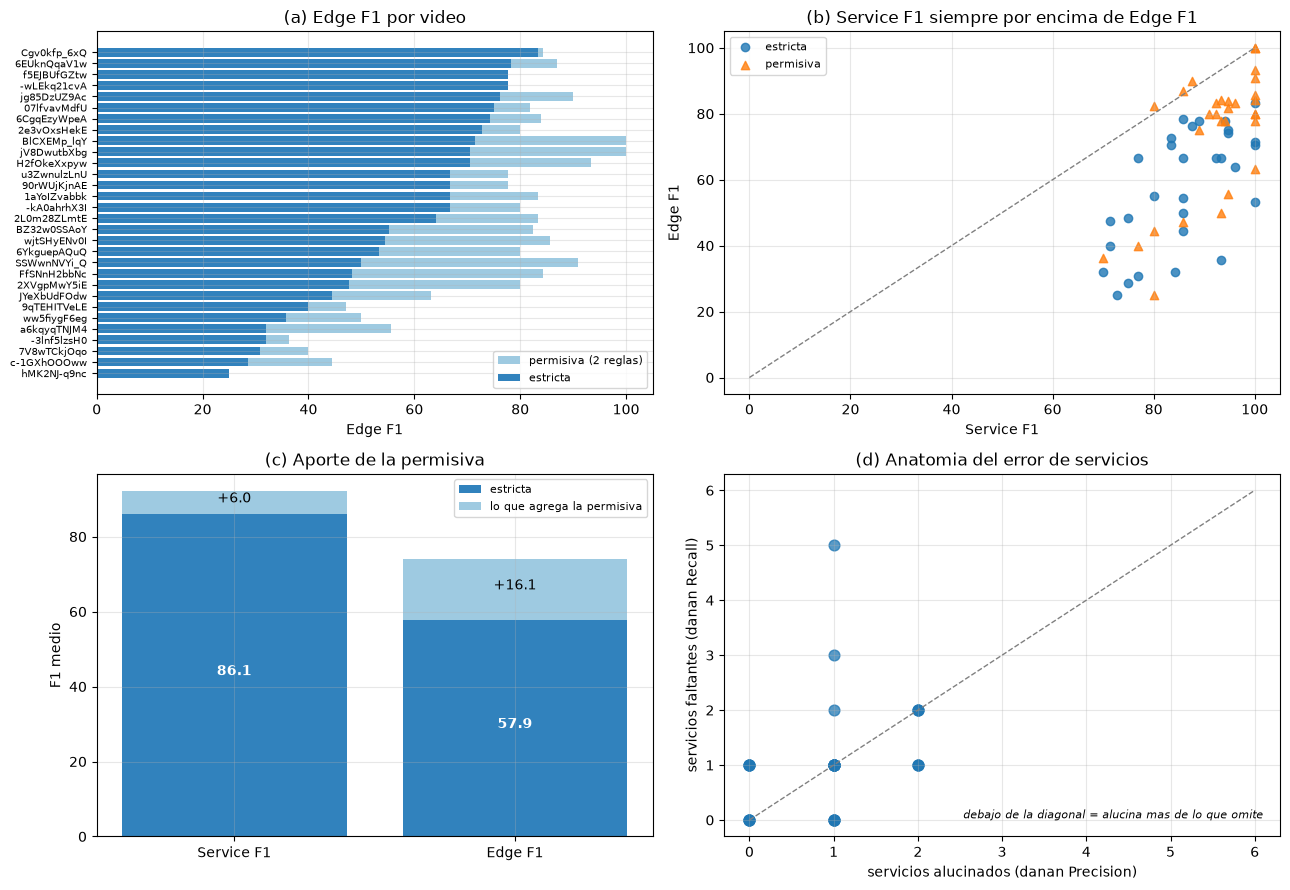

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) estricta vs permisiva por video
ax = axes[0, 0]
y = np.arange(len(df))
ax.barh(y, df["edge_permisiva"], color="#9ecae1", label="permisiva (2 reglas)")
ax.barh(y, df["edge_estricta"],  color="#3182bd", label="estricta")
ax.set_yticks(y); ax.set_yticklabels(df.index, fontsize=7)
ax.set_xlabel("Edge F1"); ax.set_title("(a) Edge F1 por video"); ax.legend(fontsize=8)

# (b) dispersion svc vs edge
ax = axes[0, 1]
ax.scatter(df["svc_estricta"], df["edge_estricta"], label="estricta", alpha=.8)
ax.scatter(df["svc_permisiva"], df["edge_permisiva"], label="permisiva", alpha=.8, marker="^")
ax.plot([0, 100], [0, 100], ls="--", c="gray", lw=1)
ax.set_xlabel("Service F1"); ax.set_ylabel("Edge F1")
ax.set_title("(b) Service F1 siempre por encima de Edge F1"); ax.legend(fontsize=8)

# (c) cuanto sube cada metrica
ax = axes[1, 0]
ax.bar(["Service F1", "Edge F1"],
       [df["svc_estricta"].mean(), df["edge_estricta"].mean()],
       label="estricta", color="#3182bd")
ax.bar(["Service F1", "Edge F1"],
       [df["d_svc"].mean(), df["d_edge"].mean()],
       bottom=[df["svc_estricta"].mean(), df["edge_estricta"].mean()],
       label="lo que agrega la permisiva", color="#9ecae1")
for i, (base, extra) in enumerate([(df["svc_estricta"].mean(), df["d_svc"].mean()),
                                   (df["edge_estricta"].mean(), df["d_edge"].mean())]):
    ax.text(i, base / 2, f"{base:.1f}", ha="center", color="white", fontweight="bold")
    ax.text(i, base + extra / 2, f"+{extra:.1f}", ha="center")
ax.set_ylabel("F1 medio"); ax.set_title("(c) Aporte de la permisiva"); ax.legend(fontsize=8)

# (d) alucinados vs faltantes
ax = axes[1, 1]
ax.scatter(df["alucinados"], df["faltantes"], s=60, alpha=.75)
lim = max(df["alucinados"].max(), df["faltantes"].max()) + 1
ax.plot([0, lim], [0, lim], ls="--", c="gray", lw=1)
ax.set_xlabel("servicios alucinados (danan Precision)")
ax.set_ylabel("servicios faltantes (danan Recall)")
ax.set_title("(d) Anatomia del error de servicios")
ax.text(.97, .05, "debajo de la diagonal = alucina mas de lo que omite",
        transform=ax.transAxes, ha="right", fontsize=8, style="italic")

for a in axes.flat:
    a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 9 · Exportar

Se guarda el resultado por video para que cualquier tabla o gráfica del paper salga de acá
y no de un número citado de memoria.

In [17]:
OUT = Path("../reports/evaluacion_metricas_panel30.json")
payload = {
    "generado_por": "notebooks/03_evaluacion_metricas.ipynb",
    "corrida": RUN_DIR.name,
    "prompt": RUN["stage2_prompt"],
    "modelo": RUN["model"],
    "definiciones": {
        "estricta": {
            "servicios": "F1 sobre CONJUNTO unico de valores de 'service' (svc_f1). "
                         "El multiconjunto se calcula como ms_f1 y no se publica.",
            "aristas":   "F1 sobre MULTICONJUNTO de pares ORDENADOS (servicio_origen, servicio_destino). "
                         "El type de la arista no entra.",
            "fuente":    "scripts/utils/evaluate_graphs.evaluate_pair",
        },
        "permisiva_2_reglas": {
            "regla_A": "User* -> User, ThirdParty* -> ThirdParty (via columna capability del catalogo)",
            "regla_B": "aristas no dirigidas; los bidireccionales se funden a nivel de PAR DE NODOS "
                       "antes de mapear a servicios, y se conserva el multiconjunto entre pares distintos",
            "no_relaja": ["alucinar un servicio", "omitir un servicio",
                          "conectar servicios que no van conectados",
                          "cuantas veces va una conexion entre pares de nodos distintos"],
        },
        "descartada_3_reglas": "agrega colapso a conjunto (ignora duplicados). No se usa: "
                               "borra la fusion logica que el prompt implementa a proposito.",
    },
    "medias": {
        "svc_estricta":   round(df["svc_estricta"].mean(), 2),
        "svc_permisiva":  round(df["svc_permisiva"].mean(), 2),
        "edge_estricta":  round(df["edge_estricta"].mean(), 2),
        "edge_permisiva": round(df["edge_permisiva"].mean(), 2),
    },
    "anatomia_aristas_perdidas": resumen["aristas"].to_dict(),
    "por_video": df.round(4).reset_index().to_dict(orient="records"),
}
OUT.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"escrito -> {OUT}")
print(json.dumps(payload["medias"], indent=2))

escrito -> ../reports/evaluacion_metricas_panel30.json
{
  "svc_estricta": 86.13,
  "svc_permisiva": 92.15,
  "edge_estricta": 57.87,
  "edge_permisiva": 74.0
}


## Resumen de lo que hay que recordar

1. **Se compara por servicio, no por id de nodo.** Una arista es "de un `EC2` a un `S3`".
2. **Alucinar castiga vía Precision**; omitir castiga vía Recall. El F1 es la media
   armónica, así que se pega al menor de los dos.
3. **El Service F1 publicado usa conjunto:** duplicar un tipo que ya está es gratis;
   introducir un tipo nuevo que el GT no tiene es caro.
4. **El Edge F1 usa multiconjunto de pares ordenados**, y por eso es siempre mucho más
   bajo: un nodo ausente arrastra sus aristas, la dirección hay que acertarla y la cantidad
   también.
5. **La permisiva de 2 reglas** perdona solo el subtipo de actor y el sentido de la flecha.
   Todo lo demás sigue castigándose.
6. **La de 3 reglas no se usa**: colapsar a conjunto premia igual al modelo que distingue
   instancias y al que las funde.
7. **El 63.88 del `ara/` está mal etiquetado** (§7.3) — no implementa lo que dice.